<a href="https://colab.research.google.com/github/Atikuzzaman101/Oil_Price_forecast/blob/main/oil_price_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install Required Libraries

In [2]:
# Install any missing libraries (run this once)
!pip install statsmodels pmdarima tensorflow scikit-learn matplotlib pandas numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.5 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import All Libraries

In [4]:
# ── Standard libraries ──
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Statsmodels (ARMA/ARIMA) ──
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Sklearn ──
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── TensorFlow / Keras (LSTM) ──
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Plotting style ──
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0


---
# PART 1 — ARMA Model
## Load and Inspect the Data

In [5]:
# ── Load the CSV file ──
# Make sure 'oil_prices_2426.csv' is in the same folder as this notebook
df = pd.read_csv('/content/drive/MyDrive/oil_prices_2426.csv')

# ── Parse dates and set as index ──
df.columns = ['date', 'price']          # rename columns for clarity
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

# ── Basic info ──
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape          : {df.shape}")
print(f"Date range     : {df.index.min().date()} → {df.index.max().date()}")
print(f"Total records  : {len(df)} daily observations")
print("\nFirst 5 rows:")
print(df.head())
print("\nDescriptive Statistics:")
print(df.describe().round(2))

DATASET OVERVIEW
Shape          : (500, 1)
Date range     : 2024-09-21 → 2026-02-02
Total records  : 500 daily observations

First 5 rows:
            price
date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21

Descriptive Statistics:
        price
count  500.00
mean    75.87
std     42.91
min     16.48
25%     35.37
50%     64.29
75%    111.57
max    158.78


## Exploratory Data Analysis (EDA) — Initial Time Series Plot

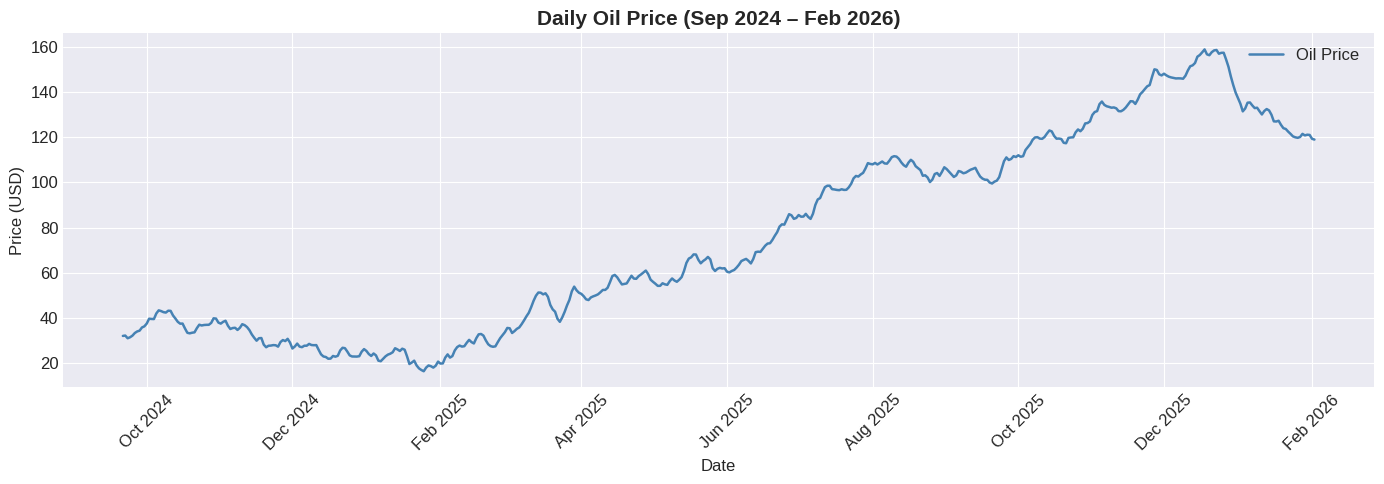

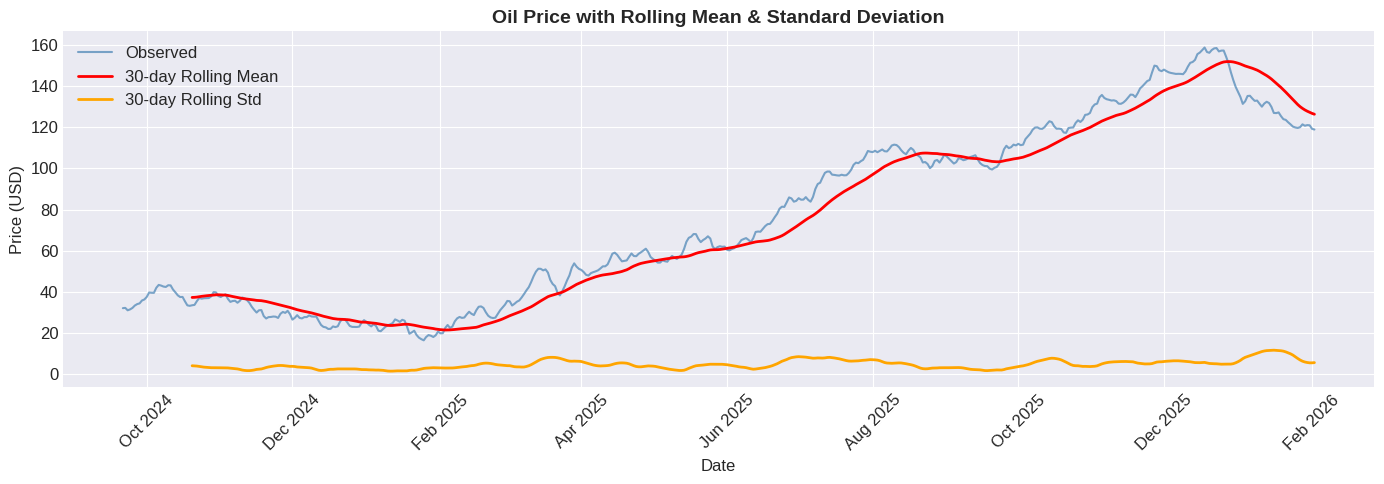

Observation: The rolling mean is clearly trending upward — this suggests the series is NON-STATIONARY.


In [6]:
def plot_time_series(series, title='Oil Price Time Series', ylabel='Price (USD)', color='steelblue'):
    """Plot a time series with formatted x-axis."""
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(series.index, series.values, color=color, linewidth=1.8, label='Oil Price')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Plot raw oil price data
plot_time_series(df['price'], title='Daily Oil Price (Sep 2024 – Feb 2026)')

# Rolling statistics plot (30-day window)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['price'], label='Observed', color='steelblue', alpha=0.7)
ax.plot(df['price'].rolling(window=30).mean(), label='30-day Rolling Mean', color='red', linewidth=2)
ax.plot(df['price'].rolling(window=30).std(), label='30-day Rolling Std', color='orange', linewidth=2)
ax.set_title('Oil Price with Rolling Mean & Standard Deviation', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Observation: The rolling mean is clearly trending upward — this suggests the series is NON-STATIONARY.")

## Stationarity Test — Augmented Dickey-Fuller (ADF)

In [7]:
def run_adf_test(series, series_name='Series'):
    """
    Run the Augmented Dickey-Fuller test for stationarity.
    H0: Series has a unit root (non-stationary)
    H1: Series is stationary
    Reject H0 if p-value < 0.05
    """
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{'='*50}")
    print(f"ADF Test: {series_name}")
    print(f"{'='*50}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")

    if result[1] <= 0.05:
        print("\n✅ RESULT: STATIONARY (reject H0, p ≤ 0.05)")
    else:
        print("\n❌ RESULT: NON-STATIONARY (fail to reject H0, p > 0.05)")
    print()
    return result[1]

# Test original series
p_original = run_adf_test(df['price'], 'Original Oil Price')

ADF Test: Original Oil Price
ADF Statistic : -0.5462
p-value       : 0.882674
Lags Used     : 17
Observations  : 482
Critical Values:
   1%: -3.4440
   5%: -2.8676
   10%: -2.5700

❌ RESULT: NON-STATIONARY (fail to reject H0, p > 0.05)



## ACF and PACF Plots on Original Data

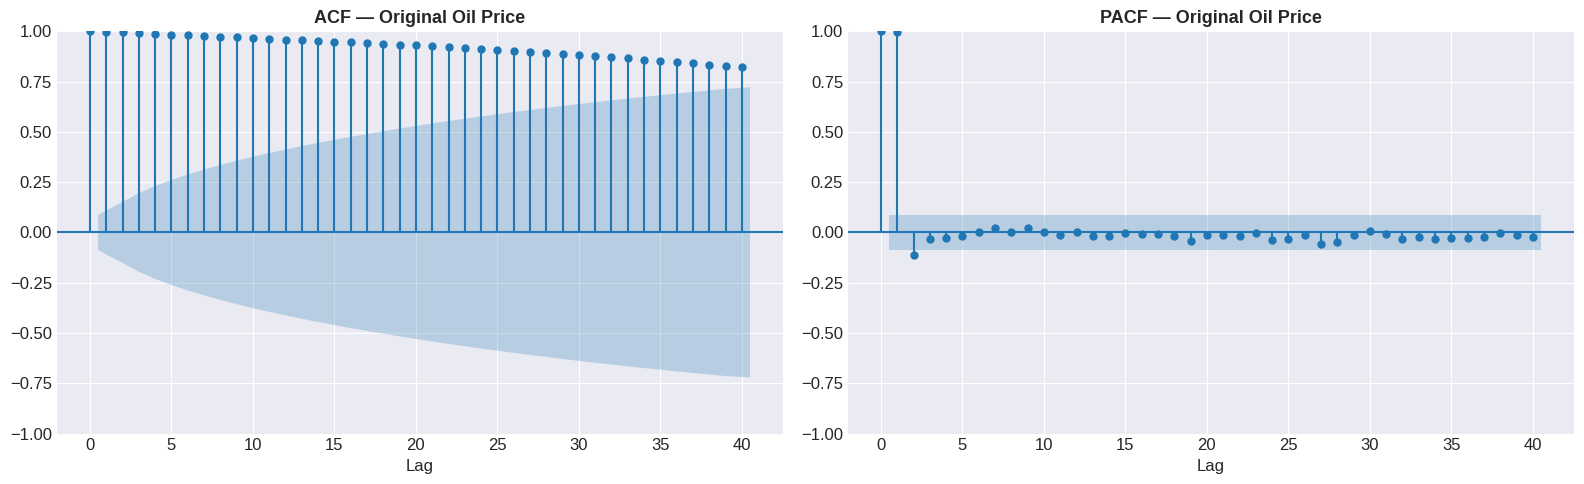

Interpretation: The ACF decays very slowly → confirms non-stationarity. Differencing is required.


In [8]:
def plot_acf_pacf(series, lags=40, title_suffix=''):
    """Plot ACF and PACF side by side for a given time series."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    plot_acf(series.dropna(), lags=lags, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF {title_suffix}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Lag')

    plot_pacf(series.dropna(), lags=lags, ax=axes[1], alpha=0.05, method='ywm')
    axes[1].set_title(f'PACF {title_suffix}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Lag')

    plt.tight_layout()
    plt.show()

# ACF/PACF on original data
plot_acf_pacf(df['price'], title_suffix='— Original Oil Price')
print("Interpretation: The ACF decays very slowly → confirms non-stationarity. Differencing is required.")

## Cell 7: Make Data Stationary — First Differencing

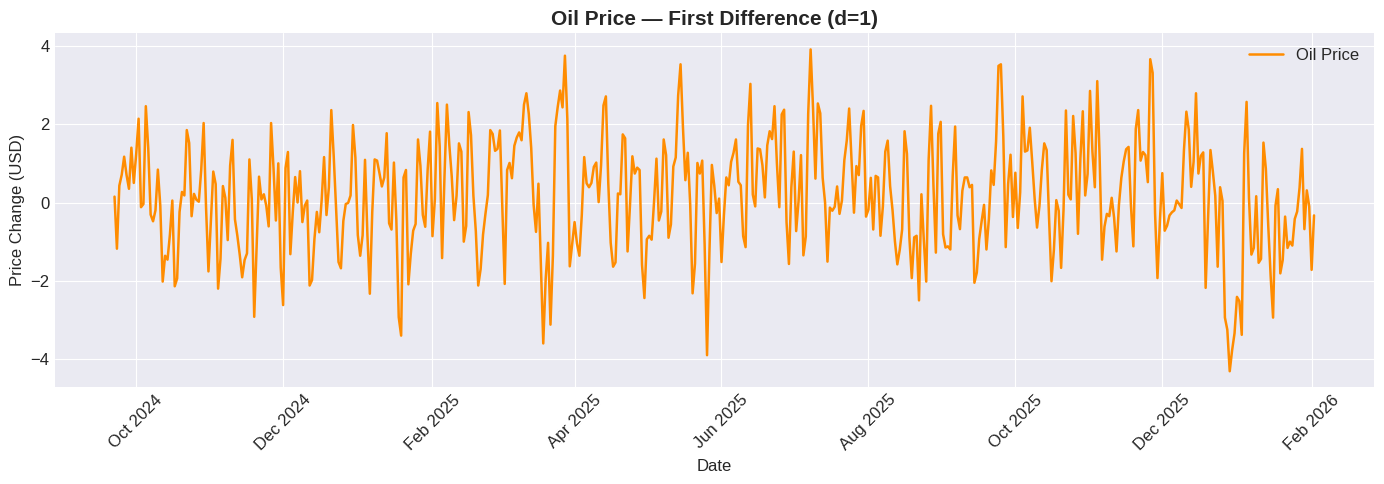

ADF Test: 1st Differenced Oil Price
ADF Statistic : -4.5415
p-value       : 0.000165
Lags Used     : 16
Observations  : 482
Critical Values:
   1%: -3.4440
   5%: -2.8676
   10%: -2.5700

✅ RESULT: STATIONARY (reject H0, p ≤ 0.05)



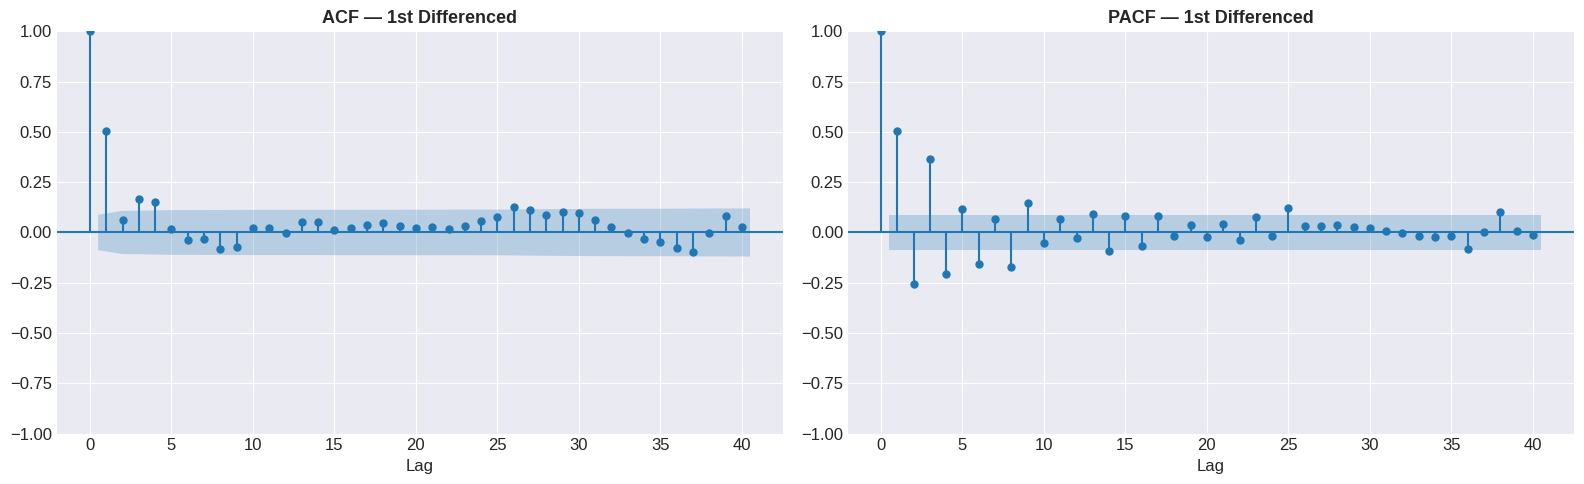

After differencing, the ADF p-value should be < 0.05 → series is now stationary.
The ACF/PACF of the differenced series helps us identify suitable p and q orders for ARMA.


In [9]:
# ── Apply first-order differencing ──
df['price_diff1'] = df['price'].diff()

# ── Plot differenced series ──
plot_time_series(
    df['price_diff1'].dropna(),
    title='Oil Price — First Difference (d=1)',
    ylabel='Price Change (USD)',
    color='darkorange'
)

# ── ADF test on differenced series ──
p_diff1 = run_adf_test(df['price_diff1'].dropna(), '1st Differenced Oil Price')

# ── ACF/PACF on differenced series ──
plot_acf_pacf(df['price_diff1'].dropna(), title_suffix='— 1st Differenced')

print("After differencing, the ADF p-value should be < 0.05 → series is now stationary.")
print("The ACF/PACF of the differenced series helps us identify suitable p and q orders for ARMA.")

## Find Best ARIMA Parameters (p, d, q) Using AIC

In [10]:
import itertools

def find_best_arima(series, p_range, d_range, q_range):
    """
    Grid search over p, d, q combinations.
    Fits ARIMA(p,d,q) and selects the model with the lowest AIC score.
    Lower AIC = better model fit with less complexity.
    """
    best_aic = np.inf
    best_params = None
    results_list = []

    combos = list(itertools.product(p_range, d_range, q_range))
    print(f"Testing {len(combos)} parameter combinations. Please wait...")

    for i, (p, d, q) in enumerate(combos):
        try:
            model = SARIMAX(
                series,
                order=(p, d, q),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            result = model.fit(disp=False)
            results_list.append({'p': p, 'd': d, 'q': q, 'AIC': result.aic})

            if result.aic < best_aic:
                best_aic = result.aic
                best_params = (p, d, q)
        except:
            continue

        # Progress indicator every 50 combos
        if (i + 1) % 50 == 0:
            print(f"  Tested {i+1}/{len(combos)} | Best so far: ARIMA{best_params} AIC={best_aic:.2f}")

    results_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)
    return best_params, best_aic, results_df

# ── Run parameter search as required by assignment ──
# p in [0,8], d in [0,2], q in [0,8]
best_params, best_aic, aic_results = find_best_arima(
    series=df['price'],
    p_range=range(0, 9),   # 0 to 8 inclusive
    d_range=range(0, 3),   # 0 to 2 inclusive
    q_range=range(0, 9)    # 0 to 8 inclusive
)

print(f"\n{'='*50}")
print(f"BEST MODEL: ARIMA{best_params}")
print(f"Best AIC  : {best_aic:.4f}")
print(f"{'='*50}")
print("\nTop 10 Models by AIC:")
print(aic_results.head(10).to_string(index=False))

Testing 243 parameter combinations. Please wait...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

  Tested 50/243 | Best so far: ARIMA(0, 2, 8) AIC=1412.00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

  Tested 100/243 | Best so far: ARIMA(2, 2, 8) AIC=1403.08


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

  Tested 200/243 | Best so far: ARIMA(2, 2, 8) AIC=1403.08


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likeli


BEST MODEL: ARIMA(2, 2, 8)
Best AIC  : 1403.0834

Top 10 Models by AIC:
 p  d  q         AIC
 2  2  8 1403.083397
 3  2  8 1404.397972
 2  2  7 1404.722379
 3  2  7 1404.782003
 4  1  8 1404.934141
 3  1  8 1405.131662
 6  2  7 1408.481258
 6  2  8 1410.952555
 0  2  8 1412.003726
 5  1  8 1412.194564


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Fit the Best ARIMA Model

In [11]:
# ── Fit the best model selected by AIC ──
p, d, q = best_params

final_model = SARIMAX(
    df['price'],
    order=(p, d, q),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_model = final_model.fit(disp=False)

# ── Display model summary ──
print(fitted_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:               SARIMAX(2, 2, 8)   Log Likelihood                -690.542
Date:                Sat, 14 Mar 2026   AIC                           1403.083
Time:                        12:01:25   BIC                           1449.199
Sample:                    09-21-2024   HQIC                          1421.196
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0723      0.020    -52.564      0.000      -1.112      -1.032
ar.L2         -0.9358      0.018    -53.073      0.000      -0.970      -0.901
ma.L1          1.1321      0.074     15.273      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Model Diagnostics — Residual Analysis

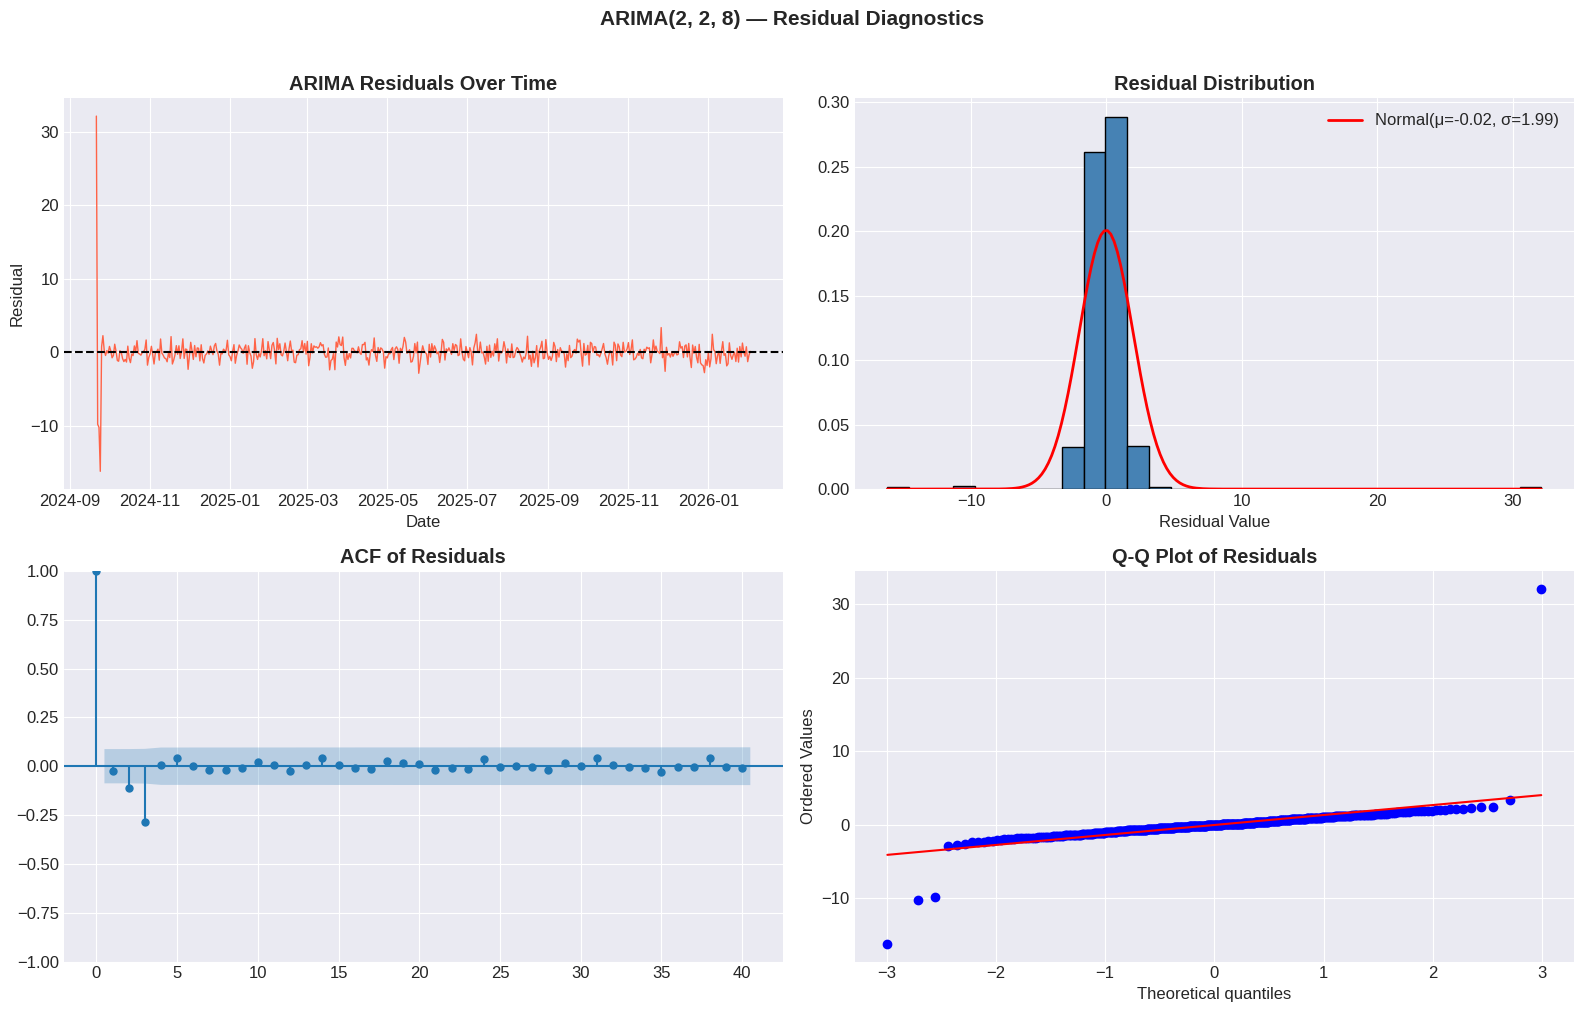

Ideal diagnostics:
  ✅ Residual plot: random scatter around zero (no pattern)
  ✅ Histogram: bell-shaped, centred near zero
  ✅ ACF of residuals: all spikes within confidence bands (white noise)
  ✅ Q-Q plot: points close to the diagonal line


In [12]:
# ── Extract model residuals ──
residuals = fitted_model.resid

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Residual time series
axes[0, 0].plot(residuals, color='tomato', linewidth=1)
axes[0, 0].axhline(0, color='black', linestyle='--')
axes[0, 0].set_title('ARIMA Residuals Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual')

# Plot 2: Residual distribution (histogram)
axes[0, 1].hist(residuals, bins=30, edgecolor='black', color='steelblue', density=True)
# Overlay normal curve
from scipy.stats import norm
mu, std = norm.fit(residuals)
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2, label=f'Normal(μ={mu:.2f}, σ={std:.2f})')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].legend()

# Plot 3: ACF of residuals (should be within confidence bands → good fit)
plot_acf(residuals, lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF of Residuals', fontweight='bold')

# Plot 4: QQ-plot
from scipy.stats import probplot
probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.suptitle(f'ARIMA{best_params} — Residual Diagnostics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Ideal diagnostics:")
print("  ✅ Residual plot: random scatter around zero (no pattern)")
print("  ✅ Histogram: bell-shaped, centred near zero")
print("  ✅ ACF of residuals: all spikes within confidence bands (white noise)")
print("  ✅ Q-Q plot: points close to the diagonal line")

# ARIMA In-Sample RMSE Evaluation

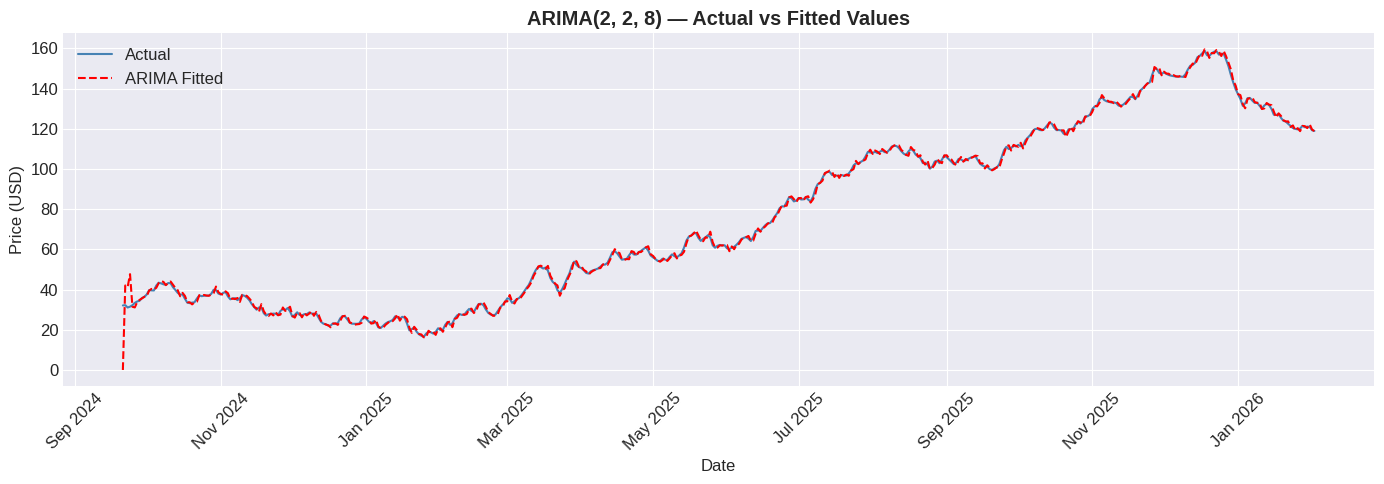

ARIMA(2, 2, 8) In-Sample — Evaluation Metrics
  RMSE : 1.9889
  MAE  : 0.9169
  MAPE : 1.93%



In [13]:
def compute_metrics(actual, predicted, model_name='Model'):
    """Calculate RMSE and MAE for model evaluation."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"{'='*40}")
    print(f"{model_name} — Evaluation Metrics")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print()
    return rmse, mae, mape

# Get in-sample fitted values from the ARIMA model
arima_fitted = fitted_model.fittedvalues

# Plot actual vs fitted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['price'], label='Actual', color='steelblue', linewidth=1.5)
ax.plot(arima_fitted, label='ARIMA Fitted', color='red', linewidth=1.5, linestyle='--')
ax.set_title(f'ARIMA{best_params} — Actual vs Fitted Values', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compute metrics
arima_rmse, arima_mae, arima_mape = compute_metrics(
    df['price'].values,
    arima_fitted.values,
    model_name=f'ARIMA{best_params} In-Sample'
)

## ARIMA 24-Month Forecast with Confidence Intervals

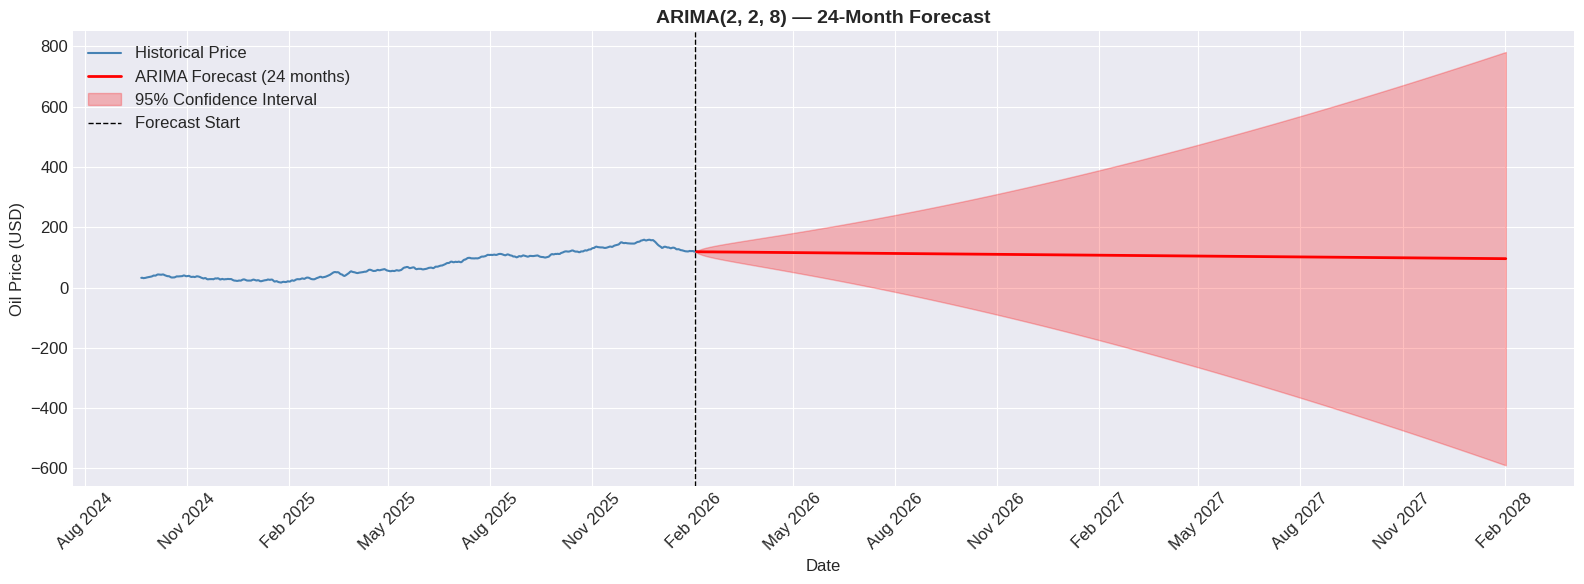

ARIMA Forecast Summary (first 5 days):
2026-02-03    119.13
2026-02-04    118.74
2026-02-05    118.47
2026-02-06    118.61
2026-02-07    118.51
Freq: D, Name: predicted_mean, dtype: float64

Forecast range: 2026-02-03 → 2028-02-02


In [14]:
def arima_forecast_plot(fitted_model, df, steps=730, model_label='ARIMA'):
    """
    Generate forecast for `steps` days ahead (~24 months = 730 days)
    and plot with 95% confidence intervals.
    """
    # Generate forecast
    forecast_obj = fitted_model.get_forecast(steps=steps)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci   = forecast_obj.conf_int(alpha=0.05)  # 95% CI

    # Build forecast date index
    last_date = df.index[-1]
    forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=steps, freq='D')
    forecast_mean.index = forecast_dates
    forecast_ci.index   = forecast_dates

    # ── Plot ──
    fig, ax = plt.subplots(figsize=(16, 6))

    # Historical data
    ax.plot(df['price'], label='Historical Price', color='steelblue', linewidth=1.5)

    # Forecast mean
    ax.plot(forecast_mean, label=f'{model_label} Forecast (24 months)', color='red', linewidth=2)

    # Confidence intervals
    ax.fill_between(
        forecast_dates,
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        alpha=0.25, color='red', label='95% Confidence Interval'
    )

    # Vertical line at forecast start
    ax.axvline(last_date, color='black', linestyle='--', linewidth=1, label='Forecast Start')

    ax.set_title(f'{model_label}{best_params} — 24-Month Forecast', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Oil Price (USD)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return forecast_mean, forecast_ci

# ── Run 24-month ARIMA forecast (~730 daily steps) ──
arima_forecast_mean, arima_forecast_ci = arima_forecast_plot(
    fitted_model, df, steps=730, model_label='ARIMA'
)

print(f"ARIMA Forecast Summary (first 5 days):")
print(arima_forecast_mean.head().round(2))
print(f"\nForecast range: {arima_forecast_mean.index.min().date()} → {arima_forecast_mean.index.max().date()}")

---
# PART 2 — LSTM Model
## LSTM Data Preparation

In [15]:
# ── LSTM requires data to be normalised and structured as sequences ──

# Step 1: Scale data to [0, 1] range using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_price = scaler.fit_transform(df['price'].values.reshape(-1, 1))

# Step 2: Define look-back window (30 days of history to predict next day)
LOOKBACK = 30

def create_sequences(data, lookback):
    """
    Create input (X) and output (y) sequences for LSTM.
    X: windows of length `lookback`
    y: the value immediately after each window
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_price, LOOKBACK)

# Step 3: Train/test split (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Step 4: Reshape for LSTM input → (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("LSTM Data Preparation Complete")
print(f"Lookback window : {LOOKBACK} days")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")
print(f"X_train shape   : {X_train.shape}  (samples, timesteps, features)")
print(f"X_test shape    : {X_test.shape}")

LSTM Data Preparation Complete
Lookback window : 30 days
Training samples: 376
Testing samples : 94
X_train shape   : (376, 30, 1)  (samples, timesteps, features)
X_test shape    : (94, 30, 1)


## Build the LSTM Model Architecture

In [16]:
def build_lstm_model(lookback, units=64, dropout_rate=0.2):
    """
    Build a stacked LSTM model:
    - Layer 1: LSTM with 64 units, returns sequences for stacking
    - Dropout: 20% regularisation to prevent overfitting
    - Layer 2: LSTM with 32 units
    - Dropout: 20%
    - Dense output layer: single neuron for regression output
    """
    model = Sequential([
        LSTM(units=units, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(dropout_rate),
        LSTM(units=units // 2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(units=1)   # single output: next day's price
    ])

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )
    return model

# Build and display model
lstm_model = build_lstm_model(lookback=LOOKBACK, units=64, dropout_rate=0.2)
lstm_model.summary()
print("\nLSTM model built successfully!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)


LSTM model built successfully!


## Train the LSTM Model

In [17]:
# ── Early stopping: stop training if validation loss stops improving ──
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,           # wait 15 epochs for improvement
    restore_best_weights=True
)

# ── Train the model ──
print("Training LSTM model... (this may take a minute)")
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,   # use 10% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")
print(f"Final training loss   : {history.history['loss'][-1]:.6f}")
print(f"Final validation loss : {history.history['val_loss'][-1]:.6f}")

Training LSTM model... (this may take a minute)
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0242 - val_loss: 0.0281
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023 - val_loss: 0.0017
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0025 - val_loss: 4.3143e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0019 - val_loss: 0.0033
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0021 - val_loss: 0.0016


## Plot LSTM Training Loss Curve

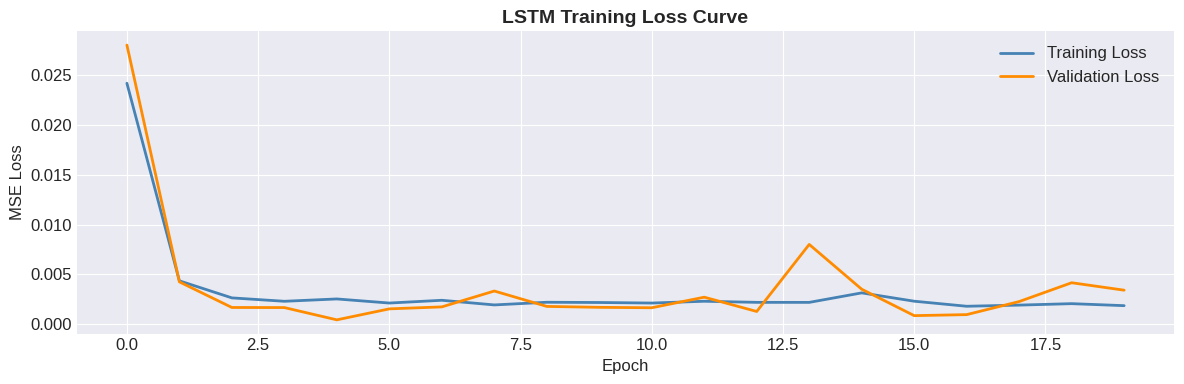

A good model shows both curves decreasing and converging without overfitting.


In [18]:
# ── Training vs Validation Loss ──
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'], label='Training Loss', color='steelblue', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
ax.set_title('LSTM Training Loss Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

print("A good model shows both curves decreasing and converging without overfitting.")



## LSTM Evaluation — Predicted vs Actual

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


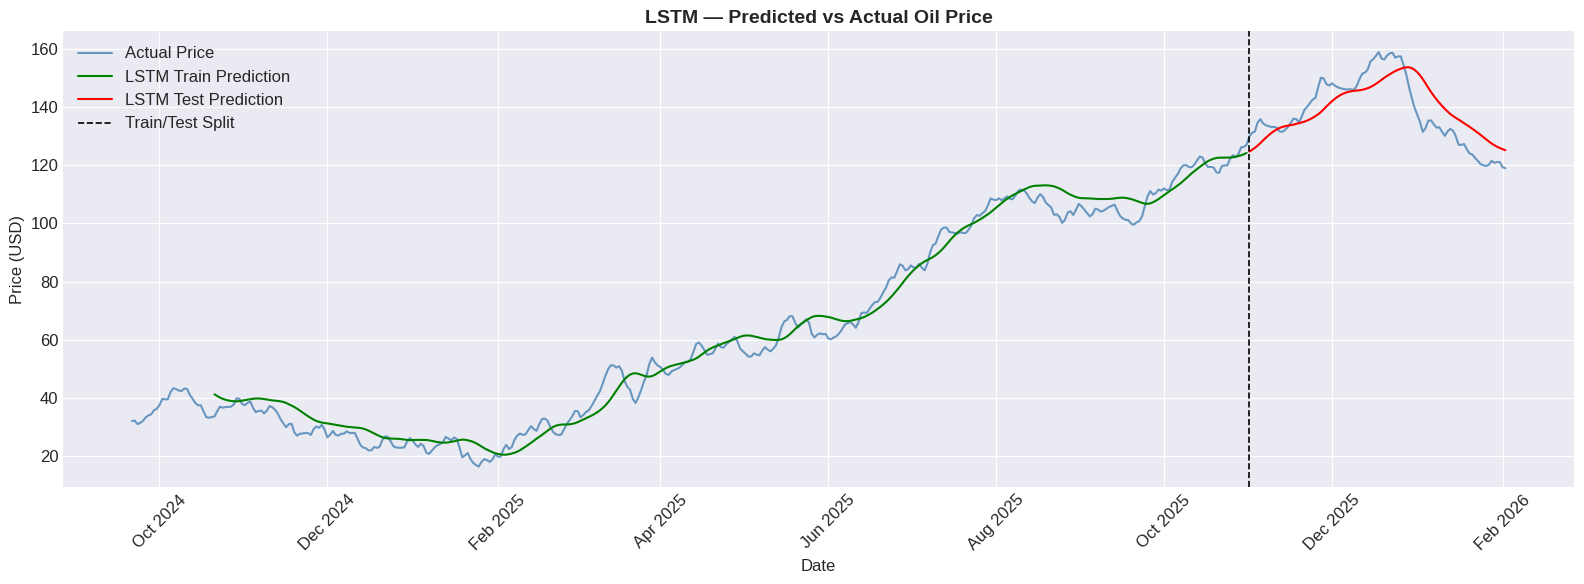

LSTM Train — Evaluation Metrics
  RMSE : 4.3275
  MAE  : 3.5571
  MAPE : 7.91%

LSTM Test — Evaluation Metrics
  RMSE : 7.3212
  MAE  : 6.2955
  MAPE : 4.61%



In [19]:
# ── Make predictions on train and test sets ──
train_pred_scaled = lstm_model.predict(X_train)
test_pred_scaled  = lstm_model.predict(X_test)

# ── Inverse transform back to original price scale ──
train_pred = scaler.inverse_transform(train_pred_scaled)
test_pred  = scaler.inverse_transform(test_pred_scaled)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual  = scaler.inverse_transform(y_test.reshape(-1, 1))

# ── Build date indices ──
train_dates = df.index[LOOKBACK:LOOKBACK + len(train_pred)]
test_dates  = df.index[LOOKBACK + len(train_pred):LOOKBACK + len(train_pred) + len(test_pred)]

# ── Plot ──
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['price'], label='Actual Price', color='steelblue', linewidth=1.5, alpha=0.8)
ax.plot(train_dates, train_pred, label='LSTM Train Prediction', color='green', linewidth=1.5)
ax.plot(test_dates, test_pred, label='LSTM Test Prediction', color='red', linewidth=1.5)
ax.axvline(test_dates[0], color='black', linestyle='--', linewidth=1.2, label='Train/Test Split')
ax.set_title('LSTM — Predicted vs Actual Oil Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Compute evaluation metrics ──
lstm_rmse_train, lstm_mae_train, _ = compute_metrics(y_train_actual.flatten(), train_pred.flatten(), 'LSTM Train')
lstm_rmse_test, lstm_mae_test, _   = compute_metrics(y_test_actual.flatten(), test_pred.flatten(), 'LSTM Test')

## LSTM 24-Month Forecast

Generating LSTM 24-month forecast... (iterative prediction, please wait)


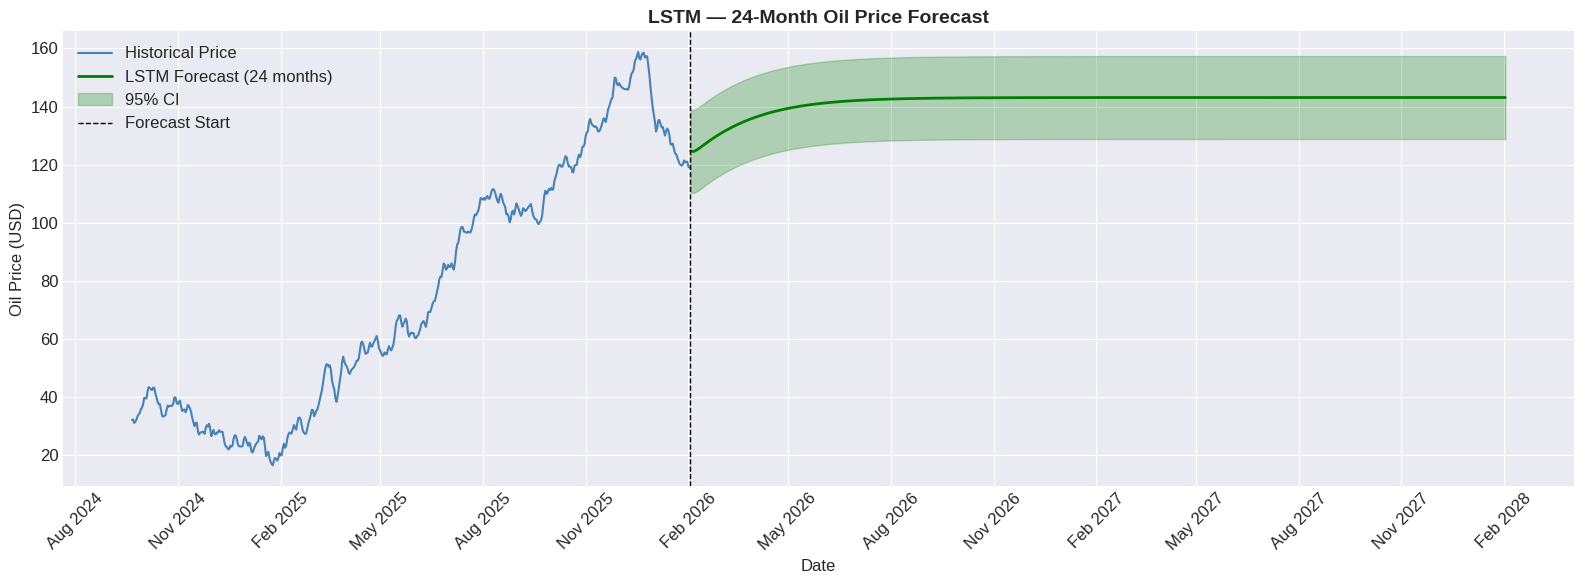

LSTM Forecast range: 2026-02-03 → 2028-02-02
Forecast first 5 values: [124.73 124.56 124.54 124.61 124.76]


In [20]:
def lstm_future_forecast(model, scaled_data, scaler, steps=730, lookback=30):
    """
    Generate multi-step future forecast using the LSTM model.
    Uses iterative (recursive) prediction:
    each prediction becomes part of the input for the next step.
    """
    predictions = []
    # Seed: last `lookback` known values
    current_seq = scaled_data[-lookback:].reshape(1, lookback, 1)

    for _ in range(steps):
        next_pred = model.predict(current_seq, verbose=0)
        predictions.append(next_pred[0, 0])
        # Slide the window forward: drop oldest, add new prediction
        current_seq = np.append(current_seq[:, 1:, :], next_pred.reshape(1, 1, 1), axis=1)

    # Inverse-transform predictions back to USD
    predictions_array = np.array(predictions).reshape(-1, 1)
    return scaler.inverse_transform(predictions_array).flatten()

# ── Run LSTM forecast ──
print("Generating LSTM 24-month forecast... (iterative prediction, please wait)")
lstm_future = lstm_future_forecast(
    model=lstm_model,
    scaled_data=scaled_price,
    scaler=scaler,
    steps=730,
    lookback=LOOKBACK
)

# ── Build forecast dates ──
last_date = df.index[-1]
lstm_forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=730, freq='D')

# ── Compute confidence intervals using rolling std of residuals ──
# Approximate CI: ± 1.96 * std of test residuals
test_residuals_std = np.std(y_test_actual.flatten() - test_pred.flatten())
ci_upper = lstm_future + 1.96 * test_residuals_std
ci_lower = lstm_future - 1.96 * test_residuals_std

# ── Plot LSTM forecast ──
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['price'], label='Historical Price', color='steelblue', linewidth=1.5)
ax.plot(lstm_forecast_dates, lstm_future, label='LSTM Forecast (24 months)', color='green', linewidth=2)
ax.fill_between(lstm_forecast_dates, ci_lower, ci_upper, alpha=0.25, color='green', label='95% CI')
ax.axvline(last_date, color='black', linestyle='--', linewidth=1, label='Forecast Start')
ax.set_title('LSTM — 24-Month Oil Price Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Oil Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"LSTM Forecast range: {lstm_forecast_dates[0].date()} → {lstm_forecast_dates[-1].date()}")
print(f"Forecast first 5 values: {lstm_future[:5].round(2)}")

---
# PART 3 — Comparison & Summary
## ARIMA vs LSTM Combined Forecast Comparison Plot

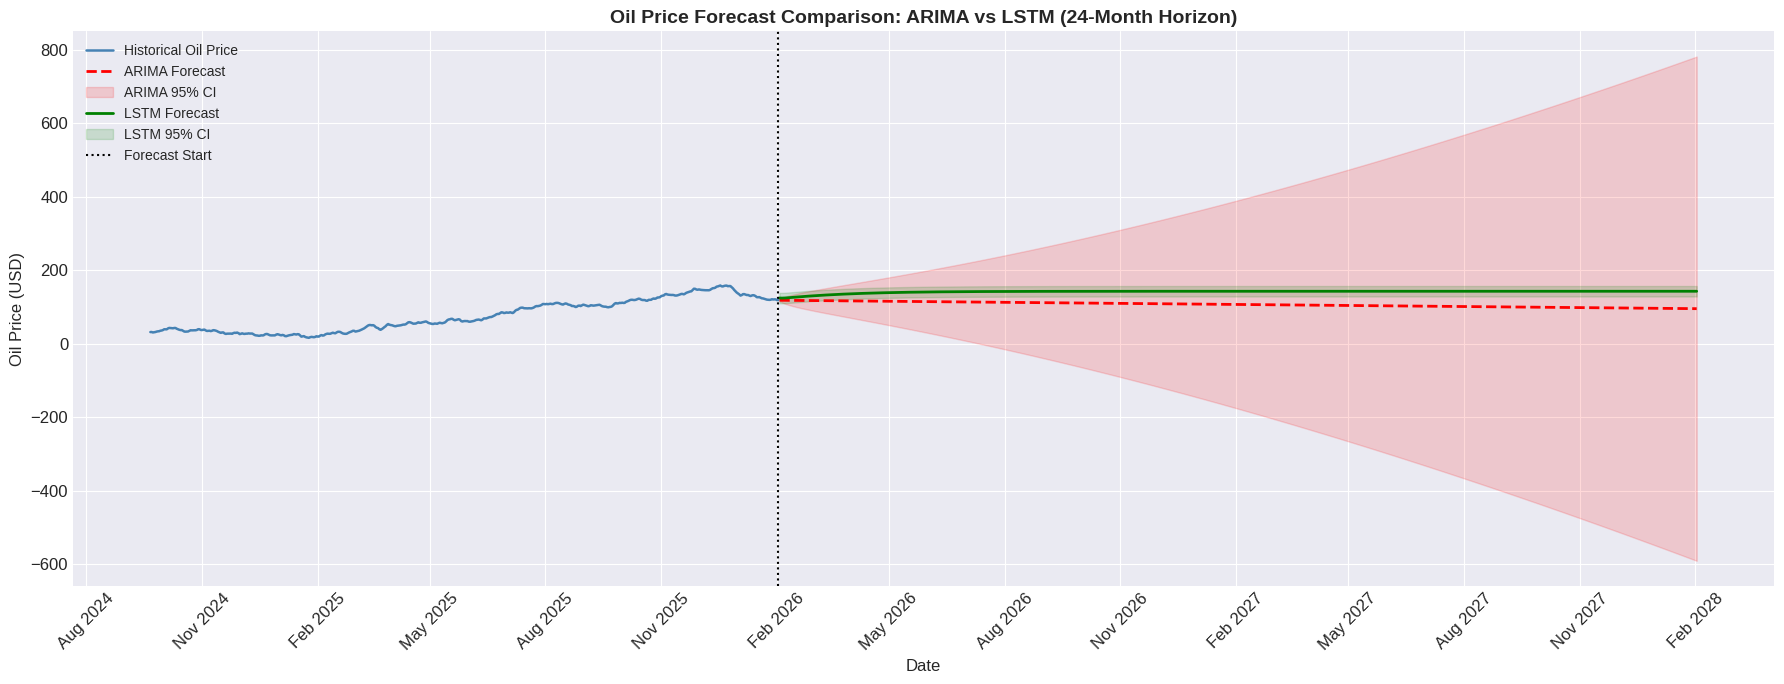

Figure saved as 'forecast_comparison.png'


In [21]:
# ── Combined comparison plot (key figure for the report) ──
fig, ax = plt.subplots(figsize=(18, 7))

# Historical data
ax.plot(df['price'], label='Historical Oil Price', color='steelblue', linewidth=1.8, zorder=5)

# ARIMA forecast
ax.plot(arima_forecast_mean, label='ARIMA Forecast', color='red', linewidth=2, linestyle='--')
ax.fill_between(
    arima_forecast_mean.index,
    arima_forecast_ci.iloc[:, 0],
    arima_forecast_ci.iloc[:, 1],
    alpha=0.15, color='red', label='ARIMA 95% CI'
)

# LSTM forecast
ax.plot(lstm_forecast_dates, lstm_future, label='LSTM Forecast', color='green', linewidth=2)
ax.fill_between(lstm_forecast_dates, ci_lower, ci_upper, alpha=0.15, color='green', label='LSTM 95% CI')

# Forecast start line
ax.axvline(last_date, color='black', linestyle=':', linewidth=1.5, label='Forecast Start')

ax.set_title('Oil Price Forecast Comparison: ARIMA vs LSTM (24-Month Horizon)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Oil Price (USD)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'forecast_comparison.png'")

## Final Model Comparison Summary Table

In [22]:
# ── Summary comparison of ARIMA vs LSTM ──
summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'Model Type', 'Parameters', 'Interpretability', 'Captures Non-linearity'],
    f'ARIMA{best_params}': [
        f'{arima_rmse:.4f}',
        f'{arima_mae:.4f}',
        'Statistical (linear)',
        f'p={p}, d={d}, q={q}',
        'High',
        'No'
    ],
    'LSTM': [
        f'{lstm_rmse_test:.4f}',
        f'{lstm_mae_test:.4f}',
        'Deep Learning (non-linear)',
        '64 & 32 units, 2 layers',
        'Low (black box)',
        'Yes'
    ]
})

print("=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print("\nKey Takeaways:")
print("  • ARIMA is interpretable and fast, but assumes linear relationships.")
print("  • LSTM captures complex non-linear patterns but requires more data & compute.")
print("  • The model with lower RMSE on test data generalises better.")
print("  • Both models' forecast uncertainty grows with prediction horizon.")

MODEL COMPARISON SUMMARY
                Metric       ARIMA(2, 2, 8)                       LSTM
                  RMSE               1.9889                     7.3212
                   MAE               0.9169                     6.2955
            Model Type Statistical (linear) Deep Learning (non-linear)
            Parameters        p=2, d=2, q=8    64 & 32 units, 2 layers
      Interpretability                 High            Low (black box)
Captures Non-linearity                   No                        Yes

Key Takeaways:
  • ARIMA is interpretable and fast, but assumes linear relationships.
  • LSTM captures complex non-linear patterns but requires more data & compute.
  • The model with lower RMSE on test data generalises better.
  • Both models' forecast uncertainty grows with prediction horizon.


## Save All Key Figures for the Report

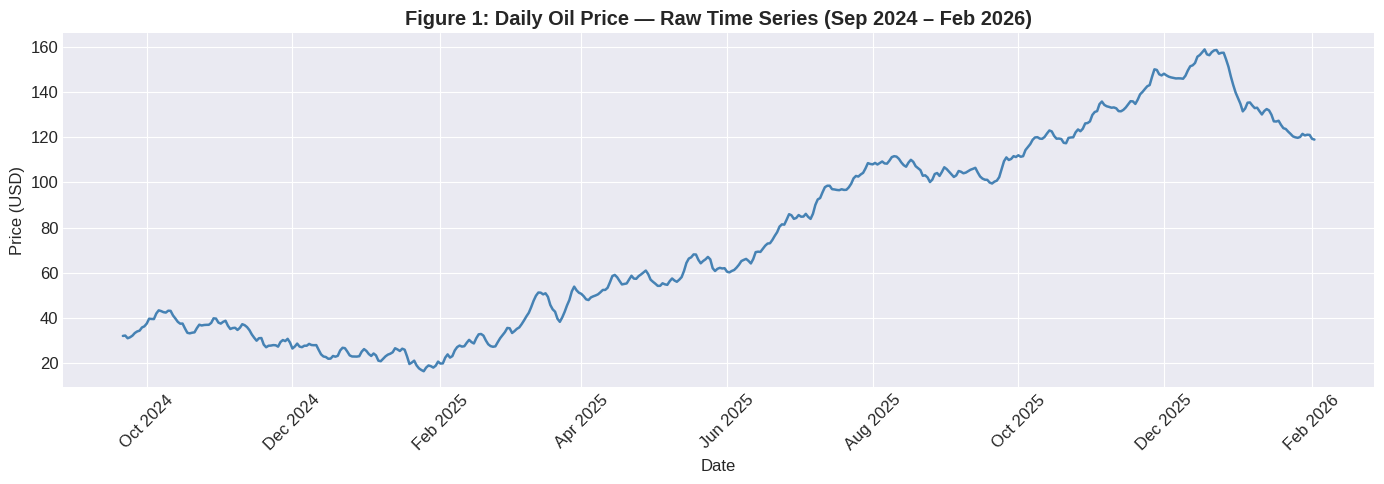

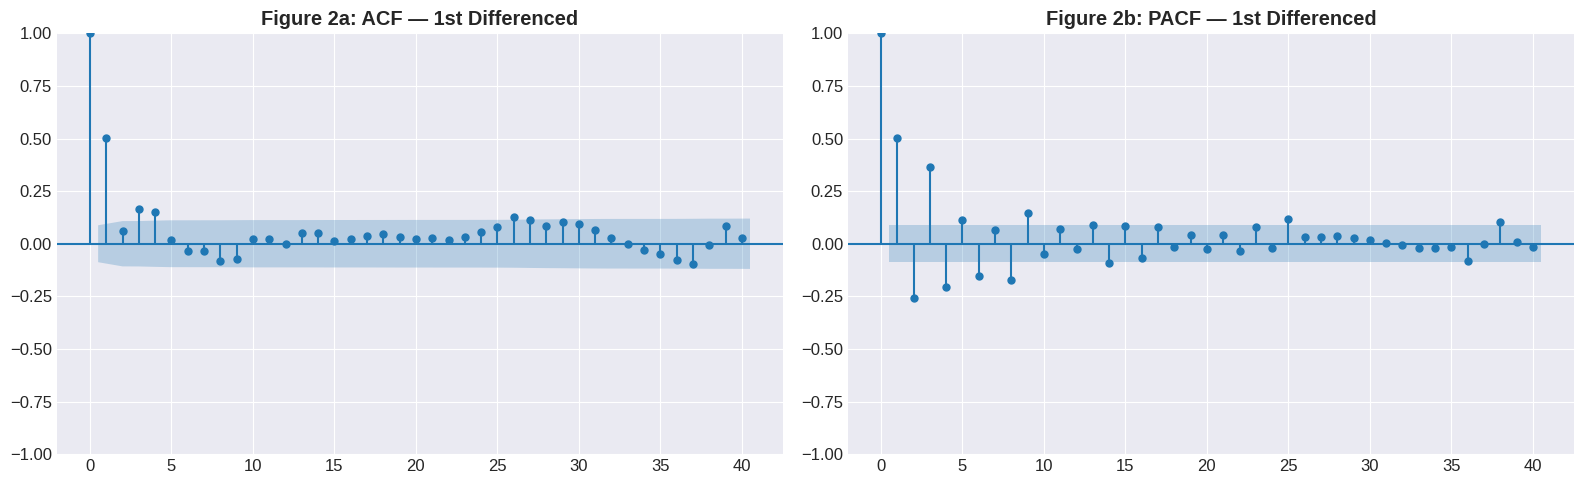

All figures saved:
  fig1_raw_series.png
  fig2_acf_pacf.png
  forecast_comparison.png  (saved in Cell 19)


In [25]:
# ── Re-save all key figures with higher resolution for inclusion in the report ──

# Figure 1: Original time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['price'], color='steelblue', linewidth=1.8)
ax.set_title('Figure 1: Daily Oil Price — Raw Time Series (Sep 2024 – Feb 2026)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig1_raw_series.png', dpi=150)
plt.show()

# Figure 2: ACF & PACF (differenced)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['price_diff1'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Figure 2a: ACF — 1st Differenced', fontweight='bold')
plot_pacf(df['price_diff1'].dropna(), lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Figure 2b: PACF — 1st Differenced', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_acf_pacf.png', dpi=150)
plt.show()

print("All figures saved:")
print("  fig1_raw_series.png")
print("  fig2_acf_pacf.png")
print("  forecast_comparison.png  (saved in Cell 19)")